In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(ROOT)

sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "eval"))

from eval.exp.exp5_llm_init import run_exp5

/Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset
Description: Default model
Model downloaded successfully to: /Users/milanliessens/.cache/fxencoder_plusplus/models--yytung--fxencoder-plusplus/snapshots/d6ed786a5fa20126402121ba8e28e1a6427eea52/fxenc_plusplus_default.pt


/Users/milanliessens/miniconda3/envs/pwfx/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Load our best checkpoint in the paper.
The checkpoint is already downloaded
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm2.we

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Load our best checkpoint in the paper.
The checkpoint is already downloaded
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm2.we

In [3]:
from src.llms.llmclient import LLMClient
from src.embeddings.clap import CLAPWrapper
llm  = LLMClient()
clap = CLAPWrapper(device='cpu')
print("Models loaded.\n")


✓ LLM client ready


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Models loaded.



In [4]:
import eval.config as cfg

In [7]:
results = run_exp5(
    llm_client=llm,
    clap=clap,
    words=cfg._WORDS_PCA_SOCIAL_EQ,
    device = cfg.DEVICE,
    n_clap_calls = 100,
    effects = ['eq']
)

✓ DASP FX chain ['eq'] created: 18 parameters
[exp5] SKIP bright/piano: both methods exist
[exp5] SKIP bright/violin: both methods exist
[exp5] RUN  calm/piano
✓ Saved original audio to: /Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset/eval/system_outputs/exp5/llm/calm/piano/intermediate/00_original.wav
  Initializing parameters using LLM...
Generating new parameters using LLM client...
LLM generated parameters based on the following instruction:  This is This is a piano playing.. Make this sound more calm.
✓ LLM generated 18 parameters
✓ Saved llm stage to: /Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset/eval/system_outputs/exp5/llm/calm/piano/intermediate/01_llm.wav
✓ Saved original audio to: /Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset/eval/system_outputs/exp5/llm_clap/calm/piano/intermediate/00

 10%|█         | 10/100 [00:02<00:24,  3.72it/s]

  Iter   9: loss = 0.9216


 20%|██        | 20/100 [00:05<00:21,  3.67it/s]

  Iter  19: loss = 0.9153


...

 90%|█████████ | 90/100 [00:28<00:03,  3.21it/s]

  Iter  89: loss = 0.8849


100%|██████████| 100/100 [00:31<00:00,  3.17it/s]

  Iter  99: loss = 0.8828
✓ Done! Final loss = 0.8828
📊 Final params (normalized): [0.20709991 0.5250225  0.72798866 0.61004573 0.5889915  0.44506887
 0.5768818  0.4430386  0.802914   0.8078087  0.4048366  0.77521515
 0.589749   0.5958342  0.6166012  0.80205274 0.60620505 0.5064657 ]


saving the intermediate audio and params for 12 optimization steps to: /Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset/eval/system_outputs/exp5/llm_clap/warm/violin/intermediate/optimization_steps
✓ Saved 1 intermediate snapshots
✓ Saved 2 intermediate snapshots
✓ Saved 3 intermediate snapshots
✓ Saved 4 intermediate snapshots
✓ Saved 5 intermediate snapshots
✓ Saved 6 intermediate snapshots
✓ Saved 7 intermediate snapshots
✓ Saved 8 intermediate snapshots
✓ Saved 9 intermediate snapshots
✓ Saved 10 intermediate snapshots
✓ Saved 11 intermediate snapshots
✓ Saved 12 intermediate snapshots
✓ Saved CLAP refinement stage to: /Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset/eval/system_outputs/exp5/llm_clap/warm/violin/intermediate/02_clap.wav
[exp5] warm/violin: 1 files saved


In [5]:
from src.metrics.run_metrics import run_metrics_solo, run_metrics_against_gt, run_iteration_improvement_metrics

In [14]:
run_metrics_against_gt(
    gt_folder=ROOT / "eval" / "gt_cache" / "one-shot" ,
    test_folders={
            "llm": "./eval/system_outputs/exp5/llm",
            "clap_loss": "./eval/system_outputs/exp5/llm_clap",
        },
)

[autoreload of src.metrics.run_metrics failed: Traceback (most recent call last):
  File "/Users/milanliessens/miniconda3/envs/pwfx/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/milanliessens/miniconda3/envs/pwfx/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/Users/milanliessens/miniconda3/envs/pwfx/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1017, in get_code
  File "<frozen importlib._bootstrap_external>", line 947, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/Users/milanliessens/Documents/Education/Universities/Berkel


  Metrics against GT
  GT folder:        /Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset/eval/gt_cache/one-shot
  Test folders:      {'llm': './eval/system_outputs/exp5/llm', 'clap_loss': './eval/system_outputs/exp5/llm_clap'}

  ── llm ──
    Common (word, instrument) pairs: 2


100%|██████████| 2/2 [00:13<00:00,  6.96s/it]



  ── clap_loss ──
    Common (word, instrument) pairs: 2


100%|██████████| 2/2 [00:00<00:00,  2.92it/s]


  ── llm ──
    MMD (DSP, overall): 0.3936
      bright      : 0.3936
    DSP distance to GT centroid (overall): 1812.5745
      bright      : 1812.5745
    FXEnc cosine distance (overall): 0.2161
      bright      : 0.2161

  ── clap_loss ──
    MMD (DSP, overall): 0.4372
      bright      : 0.4372
    DSP distance to GT centroid (overall): 1140.9109
      bright      : 1140.9109
    FXEnc cosine distance (overall): 0.2627
      bright      : 0.2627

  Comparison ordering (against GT, lower is better):
    1. llm          | MMD=0.3936 | DSP=1812.5745 | FXEnc=0.2161
    2. clap_loss    | MMD=0.4372 | DSP=1140.9109 | FXEnc=0.2627

  Report saved (json): eval/results/metrics_against_gt_2026-03-24_17-53-03.json
  Report saved (txt):  eval/results/metrics_against_gt_2026-03-24_17-53-03.txt


{'llm': {'mmd_dsp_per_word': {'bright': 0.3935814654426869},
  'mmd_dsp_overall': 0.3935814654426869,
  'dsp_distance_per_word': {'bright': 1812.574462890625},
  'dsp_distance_overall': 1812.574462890625,
  'fxenc_distance_per_word': {'bright': 0.21605993845391647},
  'fxenc_distance_overall': 0.21605993845391647},
 'clap_loss': {'mmd_dsp_per_word': {'bright': 0.4372412597157208},
  'mmd_dsp_overall': 0.4372412597157208,
  'dsp_distance_per_word': {'bright': 1140.9109497070312},
  'dsp_distance_overall': 1140.9109497070312,
  'fxenc_distance_per_word': {'bright': 0.26267051910187245},
  'fxenc_distance_overall': 0.26267051910187245}}

In [21]:
results = run_iteration_improvement_metrics(
        test_folders={
            "llm_clap": "eval/system_outputs/exp5/llm_clap",
        },
        search_patterns={
            "llm_clap": "intermediate/optimization_steps/iter_*.wav",
        },
        gt_folder=ROOT / "eval" / "gt_cache" / "one-shot"
    )


  Iterations-to-Improvement Metrics


100%|██████████| 16/16 [02:20<00:00,  8.80s/it]


  ── llm_clap ──
    Avg iterations to improve CLAP over baseline: 12.857142857142858
    Median iterations to improve: 10.0
    Improvement rate: 7/8 (0.875)
    Baseline MMD (DSP): 0.4450
    First iter improved MMD: None
    Baseline DSP distance: 1599.4954
    Baseline FXEnc distance: 0.2722
    First iter improved FXEnc: 70

  Ranking by average iterations to improve (lower is better):
      1. llm_clap     | avg_iter=12.86, improve_rate=87.50%

  Report saved (json): eval/results/metrics/metrics_iterations_2026-03-25_00-11-24.json
  Report saved (txt):  eval/results/metrics/metrics_iterations_2026-03-25_00-11-24.txt


{'llm_clap': {'baseline_clap_overall': -0.13677615957597988,
  'baseline_mmd_dsp_overall': 0.44496782450007566,
  'baseline_dsp_distance_overall': 1599.495433807373,
  'baseline_fxenc_distance_overall': 0.2721734720662863,
  'average_iterations_to_improve': 12.857142857142858,
  'median_iterations_to_improve': 10.0,
  'std_iterations_to_improve': 6.998542122237652,
  'first_iter_improved_clap_per_word': {'bright': 10,
   'calm': 10,
   'happy': 10,
   'harsh': 10,
   'heavy': 10,
   'loud': 30,
   'soft': 10,
   'warm': None},
  'first_iter_improved_dsp_distance_per_word': {'bright': 40,
   'calm': None,
   'happy': 10,
   'harsh': None,
   'heavy': None,
   'loud': None,
   'soft': 30,
   'warm': None},
  'first_iter_improved_mmd_dsp_overall': None,
  'first_iter_improved_fxenc_distance_overall': 70,
  'best_iter': 100,
  'best_clap': -0.1127822714393193,
  'improved_pairs': 7,
  'total_pairs': 8,
  'improvement_rate': 0.875,
  'trajectory': [{'iteration': 10,
    'clap_overall': -0.1

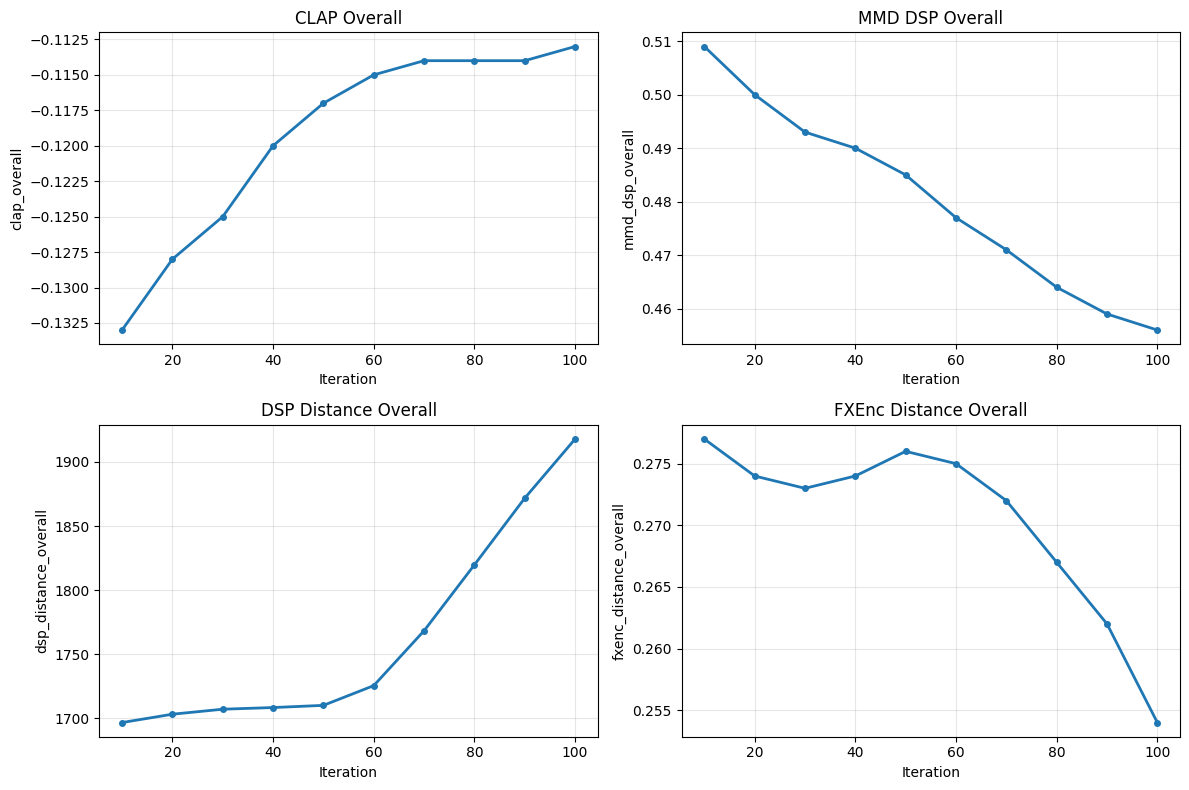

In [25]:
import matplotlib.pyplot as plt

def plot_trajectory(trajectory):
    metrics = ['clap_overall', 'mmd_dsp_overall', 'dsp_distance_overall', 'fxenc_distance_overall']
    titles = ['CLAP Overall', 'MMD DSP Overall', 'DSP Distance Overall', 'FXEnc Distance Overall']

    iterations = [d['iteration'] for d in trajectory]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, (metric, title) in enumerate(zip(metrics, titles)):
        values = [d[metric] for d in trajectory]
        axes[i].plot(iterations, values, marker='o', linewidth=2, markersize=4)
        axes[i].set_title(title)
        axes[i].set_xlabel('Iteration')
        axes[i].set_ylabel(metric)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('trajectory_plot.png', dpi=150, bbox_inches='tight')
    plt.show()


trajectory = [
    {'iteration': 10, 'clap_overall': -0.133, 'mmd_dsp_overall': 0.509, 'dsp_distance_overall': 1696.8, 'fxenc_distance_overall': 0.277},
    {'iteration': 20, 'clap_overall': -0.128, 'mmd_dsp_overall': 0.500, 'dsp_distance_overall': 1703.3, 'fxenc_distance_overall': 0.274},
    {'iteration': 30, 'clap_overall': -0.125, 'mmd_dsp_overall': 0.493, 'dsp_distance_overall': 1707.2, 'fxenc_distance_overall': 0.273},
    {'iteration': 40, 'clap_overall': -0.120, 'mmd_dsp_overall': 0.490, 'dsp_distance_overall': 1708.5, 'fxenc_distance_overall': 0.274},
    {'iteration': 50, 'clap_overall': -0.117, 'mmd_dsp_overall': 0.485, 'dsp_distance_overall': 1710.2, 'fxenc_distance_overall': 0.276},
    {'iteration': 60, 'clap_overall': -0.115, 'mmd_dsp_overall': 0.477, 'dsp_distance_overall': 1725.6, 'fxenc_distance_overall': 0.275},
    {'iteration': 70, 'clap_overall': -0.114, 'mmd_dsp_overall': 0.471, 'dsp_distance_overall': 1768.4, 'fxenc_distance_overall': 0.272},
    {'iteration': 80, 'clap_overall': -0.114, 'mmd_dsp_overall': 0.464, 'dsp_distance_overall': 1819.8, 'fxenc_distance_overall': 0.267},
    {'iteration': 90, 'clap_overall': -0.114, 'mmd_dsp_overall': 0.459, 'dsp_distance_overall': 1871.8, 'fxenc_distance_overall': 0.262},
    {'iteration': 100, 'clap_overall': -0.113, 'mmd_dsp_overall': 0.456, 'dsp_distance_overall': 1917.9, 'fxenc_distance_overall': 0.254},
]

plot_trajectory(trajectory)

In [17]:
run_metrics_solo(
    test_folders={
            "llm": "./eval/system_outputs/exp5/llm",
        },
)


  Comparative Metrics (no GT)
  Techniques: ['llm']

  ── llm ──
    CLAP (overall): -0.1368
    LUFS (overall): -26.2

  Comparison ordering by metric (solo):
    CLAP (higher is better):
      1. llm          | -0.1368
    LUFS (closer to -14.0 is better):
      1. llm          | -26.2 (|delta|=12.2)

  Report saved (json): eval/results/metrics/metrics_solo_2026-03-24_23-22-38.json
  Report saved (txt):  eval/results/metrics/metrics_solo_2026-03-24_23-22-38.txt


{'llm': {'clap_per_word': {'bright': -0.14000130250386,
   'calm': -0.16296307879371608,
   'happy': -0.11615625716187128,
   'harsh': -0.11238212614251808,
   'heavy': -0.11035013440401609,
   'loud': -0.1482018835242941,
   'soft': -0.17254494770097173,
   'warm': -0.13160954637659172},
  'clap_overall': -0.13677615957597988,
  'lufs_per_word': {'bright': -25.31704600418002,
   'calm': -26.45289305160945,
   'happy': -26.167643063975127,
   'harsh': -26.22781905605673,
   'heavy': -27.145596721427566,
   'loud': -26.896495761166562,
   'soft': -25.229767346996834,
   'warm': -26.45433238857153},
  'lufs_overall': -26.23644917424798}}

In [18]:
solo = run_metrics_solo(
    test_folders={
        'llm': 'eval/system_outputs/exp5/llm',
    },
    search_patterns={'llm': 'intermediate/01_llm.wav'},
    save_report=False,
    verbose=False,
)
print('solo llm clap_overall:', solo['llm']['clap_overall'])

it = run_iteration_improvement_metrics(
    test_folders={'llm_clap': 'eval/system_outputs/exp5/llm_clap'},
    search_patterns={'llm_clap': 'intermediate/optimization_steps/iter_*.wav'},
    baseline_pattern='intermediate/01_llm.wav',
)
print('iter baseline clap_overall:', it['llm_clap'].get('baseline_clap_overall'))


solo llm clap_overall: -0.13677615957597988

  Iterations-to-Improvement Metrics

  ── llm_clap ──
    Avg iterations to improve CLAP over baseline: 12.857142857142858
    Median iterations to improve: 10.0
    Improvement rate: 7/8 (0.875)

  Ranking by average iterations to improve (lower is better):
      1. llm_clap     | avg_iter=12.86, improve_rate=87.50%

  Report saved (json): eval/results/metrics/metrics_iterations_2026-03-24_23-23-13.json
  Report saved (txt):  eval/results/metrics/metrics_iterations_2026-03-24_23-23-13.txt
iter baseline clap_overall: -0.13677615957597988


In [22]:
from eval.exp.exp4_composite import run_exp4

In [45]:
run_exp4(
    llm,
    clap,
    fx_type = "eq",
    device = cfg.DEVICE,
    n_clap_calls = 1,
    effects = ['eq'],
    words = None)

✓ DASP FX chain ['eq'] created: 18 parameters
loss function is LossFunction.SEMANTIC_SIMILARITY_LOSS
⚡ Using shortened audio for CLAP: 5.0s instead of 16.0s

🎯 Refining: 'None' → 'This sound is loud and warm.'
📸 Saving snapshots every 10 iterations

⚡ Starting Gradient Descent-based refinement for 1 iterations...
⚡ Starting gradient descent refinement...


100%|██████████| 1/1 [00:00<00:00,  4.18it/s]

  Iter   0: loss = 0.8351
✓ Done! Final loss = 0.8351
📊 Final params (normalized): [0.38101542 0.3527502  0.64555264 0.9628087  0.5492317  0.7273899
 0.7315665  0.10194982 0.3855877  0.4100286  0.41747326 0.6770822
 0.5762711  0.5964116  0.94660264 0.21386772 0.8883925  0.63479865
 0.72719294 0.9660473  0.11637644 0.6373638  0.36330277 0.2303949
 0.17049673 0.9605971  0.90387684 0.3745308  0.6608265  0.9558565
 0.4746371  0.5331064  0.60556054 0.8024138  0.1341877  0.7673075
 0.32823956 0.24519955 0.77150065 0.7756824  0.96076155 0.2657248
 0.64221054 0.3371736  0.44257215 0.68233347 0.51965976 0.30726388
 0.30350587]
loss function is LossFunction.SEMANTIC_SIMILARITY_LOSS
⚡ Using shortened audio for CLAP: 5.0s instead of 16.0s



🎯 Refining: 'None' → 'tensor([[-6.4391e-02, -6.6325e-02,  4.0029e-02,  8.9177e-03,  5.7907e-02,
          1.9407e-02, -6.5217e-02, -2.2251e-02,  3.9838e-02,  2.7856e-03,
          9.2501e-03,  2.0900e-02,  2.6721e-02, -2.9058e-03,  1.2024e-02,
         -3.3038e-03,  7.1322e-03, -8.0878e-03, -1.5107e-02,  4.3863e-02,
         -7.3878e-02,  8.2819e-03, -1.3035e-02, -3.3511e-02,  5.8096e-03,
         -2.3948e-02, -7.1748e-02, -8.0024e-02, -4.1941e-02, -2.8543e-02,
          2.0045e-02, -2.1647e-02,  7.4941e-02, -1.4032e-03, -1.7685e-02,
          3.2705e-02, -4.4698e-02,  4.7450e-02, -1.9952e-02,  1.5540e-02,
         -5.1074e-02, -1.2724e-02, -3.8596e-02,  1.3917e-03, -1.1403e-02,
         -6.5266e-02, -1.4455e-02, -6.9900e-02,  3.9394e-02,  1.7496e-02,
         -3.0995e-02, -5.9326e-02, -5.5508e-02, -8.7962e-03,  9.9983e-03,
         -5.1908e-02, -1.5339e-02, -8.3358e-02,  6.1611e-05,  3.6795e-02,
          5.4019e-02, -3.5708e-02,  7.2088e-02, -1.0598e-02,  3.5311e-02,
         -5.036

100%|██████████| 1/1 [00:00<00:00,  4.92it/s]

...

LLM generated parameters based on the following instruction:  Make this sound loud.
✓ LLM generated 18 parameters
loss function is LossFunction.GUIDED_SEMANTIC_LOSS
⚡ Using shortened audio for CLAP: 5.0s instead of 11.5s

🎯 Refining: 'A harsh, distorted, muddy, unclear, oversaturated, unpleasant sound' → 'This sound is warm.'
📸 Saving snapshots every 10 iterations

⚡ Starting Gradient Descent-based refinement for 1 iterations...
⚡ Starting gradient descent refinement...


100%|██████████| 1/1 [00:00<00:00,  4.89it/s]

  Iter   0: loss = 0.6958
✓ Done! Final loss = 0.6958
📊 Final params (normalized): [0.16038245 0.6273408  0.4975     0.33111486 0.6169493  0.4975
 0.4634924  0.59133565 0.5371056  0.5638657  0.5704681  0.4490697
 0.80091244 0.60177284 0.58562136 0.9005558  0.6226533  0.5025    ]
  Initializing parameters using LLM...
Generating new parameters using LLM client...


LLM generated parameters based on the following instruction:  Make this sound loud and warm.
✓ LLM generated 18 parameters
All param sets already rendered for dry clip 0. SKIP.
All param sets already rendered for dry clip 0. SKIP.
All param sets already rendered for dry clip 0. SKIP.
All param sets already rendered for dry clip 0. SKIP.
[exp4] saved clap_concat output for loud_warm/piano to /Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset/eval/system_outputs/exp4/clap_concat/loud_warm/piano/piano_0.wav
[exp4] saved clap_concat output for loud_warm/violin to /Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset/eval/system_outputs/exp4/clap_concat/loud_warm/violin/violin_1.wav

  Metrics against GT
  GT folder:        /Users/milanliessens/Documents/Education/Universities/Berkeley/MEng/2026 - Spring/Projects/FX/code/text2preset/eval/gt_cache/one-shot
  Test folders:     

{'loud_warm': {'clap_concat_metrics_wordA': {},
  'clap_concat_metrics_wordB': {},
  'clap_avg_metrics_wordA': {},
  'clap_avg_metrics_wordB': {},
  'clap_sequential_metrics_wordA': {},
  'clap_sequential_metrics_wordB': {},
  'llm_metrics_wordA': {},
  'llm_metrics_wordB': {}}}

In [ ]:
# llm_metrics_wordA: how well does llm perform visavis wordA as gt

# now the system searches for loud_warm (the dir name as key for gt). Add a pattern to select in the filename to know which gt it should compare to.